# Volleyball Tagging System: Data Exploration

Authors: Patrick Dang, Abiola Raji

## Setup

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T
import torch
from torch.utils.data import DataLoader, random_split

import torchmetrics

In [2]:
path = Path("./VolleyballDataset_clean")

if not path.exists():
   print("Dataset not found")
else:
    print("Volleyball Dataset Found")

Volleyball Dataset Found


## Preprocessing & Data Loading

In [3]:
from model.transformations import train_transform, val_transform

BATCH = 32

torch.manual_seed(12345)

train_set = ImageFolder(path / "train", train_transform)
val_set = ImageFolder(path / "valid", val_transform)

# Data Loaders
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH)

### Class Distribution

In [4]:
class_names = train_set.classes
print(len(class_names),"classes")
class_names

5 classes


['block', 'defense', 'serve', 'set', 'spike']

In [5]:
from collections import Counter

all_labels = [label for _, label in train_set.samples]
counts = Counter(all_labels)

for idx, count in sorted(counts.items()):
    print(f"{class_names[idx]:<30} {count}")

print(f"\nTotal samples: {len(all_labels)}")
print(f"Total classes: {len(class_names)}")

block                          3823
defense                        118
serve                          1444
set                            3085
spike                          3770

Total samples: 12240
Total classes: 5


/var/folders/db/8x5sc8bx3g14nljyt4k3t4kw0000gn/T/ipykernel_49468/2798266946.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


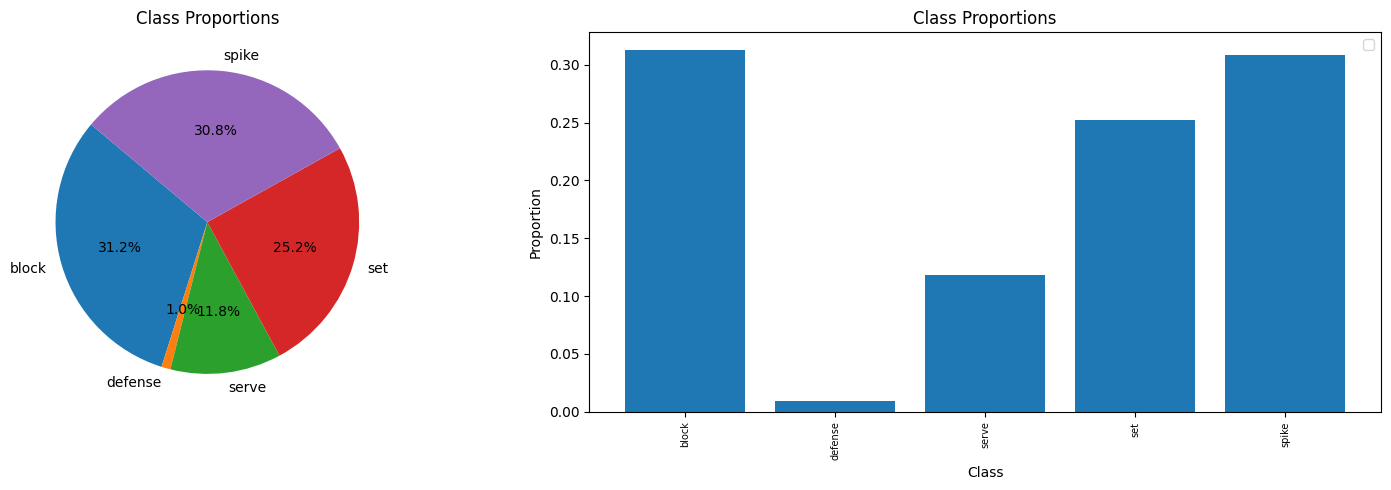

In [6]:
all_labels_train = [label for _, label in train_set.samples]
counts_train = Counter(all_labels_train)
proportions = [counts_train[i] / len(all_labels_train) for i in range(len(class_names))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie chart
axes[0].pie(proportions, labels=class_names, autopct="%1.1f%%", startangle=140)
axes[0].set_title("Class Proportions")

# Normalized bar
axes[1].bar(class_names, proportions)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Proportion")
axes[1].set_title("Class Proportions")
axes[1].legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

### Train/Validation Split

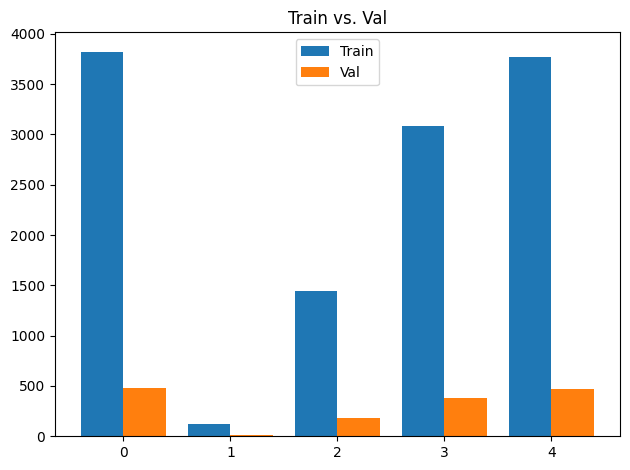

In [7]:
train_counts = Counter(label for _, label in train_set.samples)
val_counts   = Counter(label for _, label in val_set.samples)

x = np.arange(len(class_names))
width = 0.4

plt.bar(x - width/2, [train_counts[i] for i in range(len(class_names))], width, label="Train")
plt.bar(x + width/2, [val_counts[i]   for i in range(len(class_names))], width, label="Val")
plt.title("Train vs. Val")
plt.legend()

plt.tight_layout()
plt.show()

### Random Samples

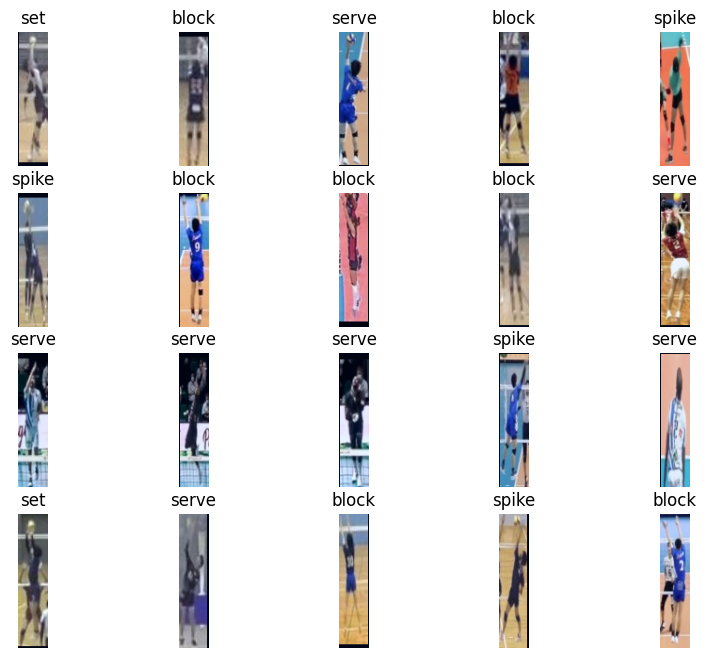

torch.Size([32, 3, 146, 32])


In [8]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 5, figsize=(10,8))
for i, ax in enumerate(axes.flatten()):
    im = images[i].permute(1, 2, 0).cpu().numpy()
    im -= im.min()
    im /= im.max()
    ax.imshow(im)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.show()

print(images.shape)

In [9]:
from PIL import Image
import numpy as np
import random

def analyze_dataset_crop_dimensions(dataset, sample_size=2000):
    widths, heights, aspect_ratios = [], [], []

    # Sample instead of full dataset
    samples = random.sample(
        dataset.samples,
        min(sample_size, len(dataset.samples))
    )

    for i, (img_path, _) in enumerate(samples):
        if i % 10 == 0:
            print(f"Processed {i}/{len(samples)}")

        with Image.open(img_path) as img:
            w, h = img.size

        widths.append(w)
        heights.append(h)
        aspect_ratios.append(h / w)

    widths        = np.array(widths)
    heights       = np.array(heights)
    aspect_ratios = np.array(aspect_ratios)

    def stats(arr, label):
        print(f"\n{label}:")
        print(f"  mean:   {np.mean(arr):.1f}")
        print(f"  median: {np.median(arr):.1f}")
        print(f"  min:    {np.min(arr):.1f}")
        print(f"  max:    {np.max(arr):.1f}")
        print(f"  p25:    {np.percentile(arr, 25):.1f}")
        print(f"  p75:    {np.percentile(arr, 75):.1f}")
        print(f"  p90:    {np.percentile(arr, 90):.1f}")

    print(f"=== CROP DIMENSION ANALYSIS — SAMPLE ===")
    print(f"samples: {len(widths)}")

    stats(widths,        "WIDTH")
    stats(heights,       "HEIGHT")
    stats(aspect_ratios, "ASPECT RATIO (h/w)")


# run it
analyze_dataset_crop_dimensions(train_set, sample_size=2000)

Processed 0/2000
Processed 10/2000
Processed 20/2000
Processed 30/2000
Processed 40/2000
Processed 50/2000
Processed 60/2000
Processed 70/2000
Processed 80/2000
Processed 90/2000
Processed 100/2000
Processed 110/2000
Processed 120/2000
Processed 130/2000
Processed 140/2000
Processed 150/2000
Processed 160/2000
Processed 170/2000
Processed 180/2000
Processed 190/2000
Processed 200/2000
Processed 210/2000
Processed 220/2000
Processed 230/2000
Processed 240/2000
Processed 250/2000
Processed 260/2000
Processed 270/2000
Processed 280/2000
Processed 290/2000
Processed 300/2000
Processed 310/2000
Processed 320/2000
Processed 330/2000
Processed 340/2000
Processed 350/2000
Processed 360/2000
Processed 370/2000
Processed 380/2000
Processed 390/2000
Processed 400/2000
Processed 410/2000
Processed 420/2000
Processed 430/2000
Processed 440/2000
Processed 450/2000
Processed 460/2000
Processed 470/2000
Processed 480/2000
Processed 490/2000
Processed 500/2000
Processed 510/2000
Processed 520/2000
Proc

[WARN] coords/train_coords.json not found — skipping
[WARN] coords/valid_coords.json not found — skipping
[WARN] coords/test_coords.json not found — skipping


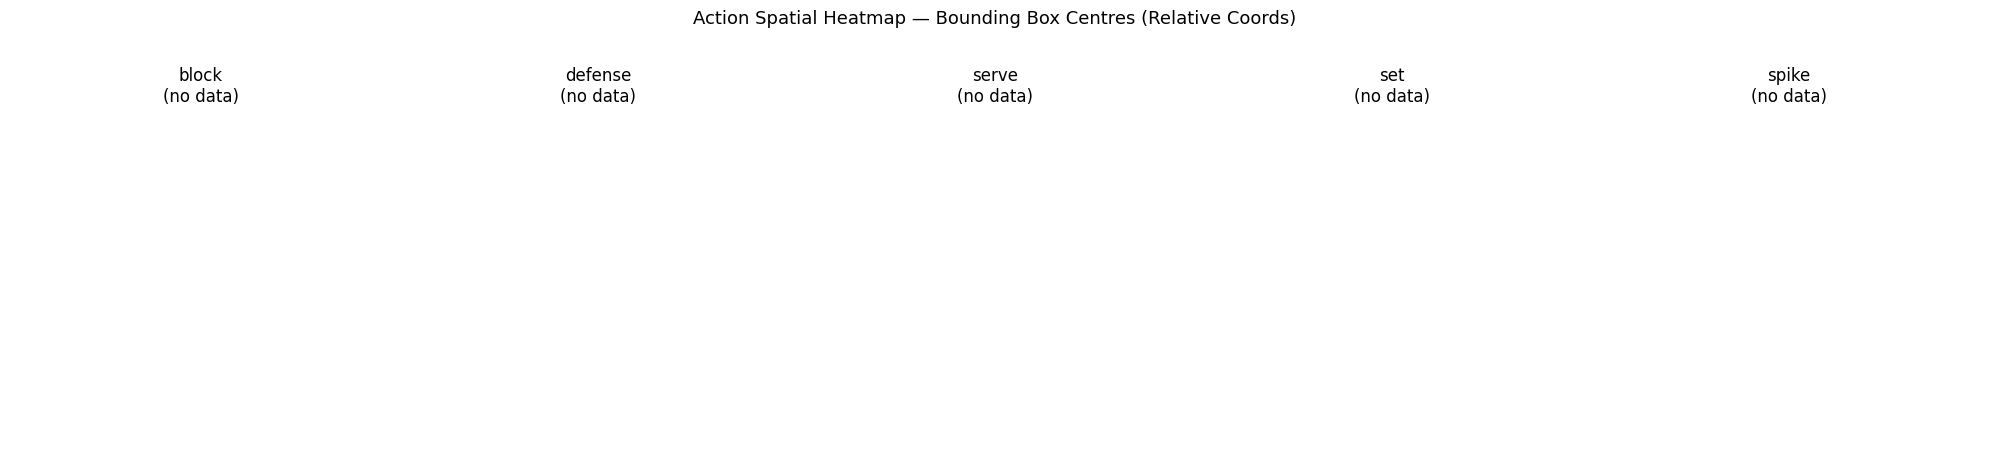


Annotation counts by class and split:
class            train     valid      test     TOTAL
----------------------------------------------------
block                0         0         0         0
defense              0         0         0         0
serve                0         0         0         0
set                  0         0         0         0
spike                0         0         0         0


In [10]:
### Action Spatial Heatmap

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Load all splits ──────────────────────────────────────────────────────────
COORDS_DIR   = Path("coords")
SPLITS       = ["train", "valid", "test"]
ACTION_CLASSES = ["block", "defense", "serve", "set", "spike"]

# Aggregate bbox_rel centre points per class across all splits
# centre = ((x1+x2)/2, (y1+y2)/2) in relative coords
centres_by_class = {cls: {"cx": [], "cy": []} for cls in ACTION_CLASSES}

for split in SPLITS:
    coord_file = COORDS_DIR / f"{split}_coords.json"
    if not coord_file.exists():
        print(f"[WARN] {coord_file} not found — skipping")
        continue

    with open(coord_file) as f:
        data = json.load(f)

    for img_entry in data["images"].values():
        for ann in img_entry["annotations"]:
            cls = ann["class"]
            if cls not in centres_by_class:
                continue
            x1r, y1r, x2r, y2r = ann["bbox_rel"]
            centres_by_class[cls]["cx"].append((x1r + x2r) / 2)
            centres_by_class[cls]["cy"].append((y1r + y2r) / 2)

n_classes = len(ACTION_CLASSES)
GRID      = 32   # heatmap resolution (32×32 bins)

fig, axes = plt.subplots(1, n_classes, figsize=(4 * n_classes, 4.5))
fig.suptitle("Action Spatial Heatmap — Bounding Box Centres (Relative Coords)",
             fontsize=13, y=1.02)

for ax, cls in zip(axes, ACTION_CLASSES):
    cx = np.array(centres_by_class[cls]["cx"])
    cy = np.array(centres_by_class[cls]["cy"])
    n  = len(cx)

    if n == 0:
        ax.set_title(f"{cls}\n(no data)")
        ax.axis("off")
        continue

    # 2D histogram → heatmap
    heatmap, xedges, yedges = np.histogram2d(cx, cy, bins=GRID, range=[[0,1],[0,1]])

    # Gaussian-blur for smooth visual (no scipy needed)
    from scipy.ndimage import gaussian_filter
    heatmap = gaussian_filter(heatmap, sigma=1.5)

    im = ax.imshow(
        heatmap.T,           # transpose: x=horizontal, y=vertical
        origin="upper",      # y=0 at top (image convention)
        extent=[0, 1, 1, 0],
        cmap="YlOrRd",
        aspect="auto",
        interpolation="bilinear",
    )

    ax.set_title(f"{cls.upper()}\n(n={n})", fontsize=10, fontweight="bold")
    ax.set_xlabel("x (left → right)", fontsize=8)
    ax.set_ylabel("y (top → bottom)", fontsize=8)
    ax.tick_params(labelsize=7)

    # Court outline
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
        spine.set_linewidth(1.5)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="density")

plt.tight_layout()
plt.show()

# ── Summary: sample counts per class per split ───────────────────────────────
print("\nAnnotation counts by class and split:")
print(f"{'class':<12}", end="")
for s in SPLITS:
    print(f"{s:>10}", end="")
print(f"{'TOTAL':>10}")
print("-" * (12 + 10 * (len(SPLITS) + 1)))

totals_per_class = {}
for cls in ACTION_CLASSES:
    row = {}
    for split in SPLITS:
        coord_file = COORDS_DIR / f"{split}_coords.json"
        if not coord_file.exists():
            row[split] = 0
            continue
        with open(coord_file) as f:
            d = json.load(f)
        row[split] = d["summary"]["class_counts"].get(cls, 0)
    totals_per_class[cls] = sum(row.values())
    print(f"{cls:<12}", end="")
    for s in SPLITS:
        print(f"{row[s]:>10}", end="")
    print(f"{totals_per_class[cls]:>10}")